--- Starting SARIMA (Seasonal ARIMA) Consumption Forecasting ---
--- Augmented Dickey-Fuller (ADF) Test ---
ADF Statistic: -1.6415
p-value: 0.4615
Critical Values:
   1%: -3.4918
   5%: -2.8884
   10%: -2.5811
Conclusion: The series is NOT stationary (p > 0.05).

Fitting SARIMA model...


c:\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Python\Python311\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
c:\Python\Python311\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'



Model Summary:
                                     SARIMAX Results                                      
Dep. Variable:                           HCLQTCON   No. Observations:                  108
Model:             SARIMAX(1, 0, 1)x(1, 1, 1, 12)   Log Likelihood               -1026.170
Date:                            Wed, 28 Jan 2026   AIC                           2062.341
Time:                                    17:44:11   BIC                           2075.163
Sample:                                01-01-2015   HQIC                          2067.524
                                     - 12-01-2023                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.6815      0.941     -0.724      0.469      -2.525       1.162
ma.L1          0.63

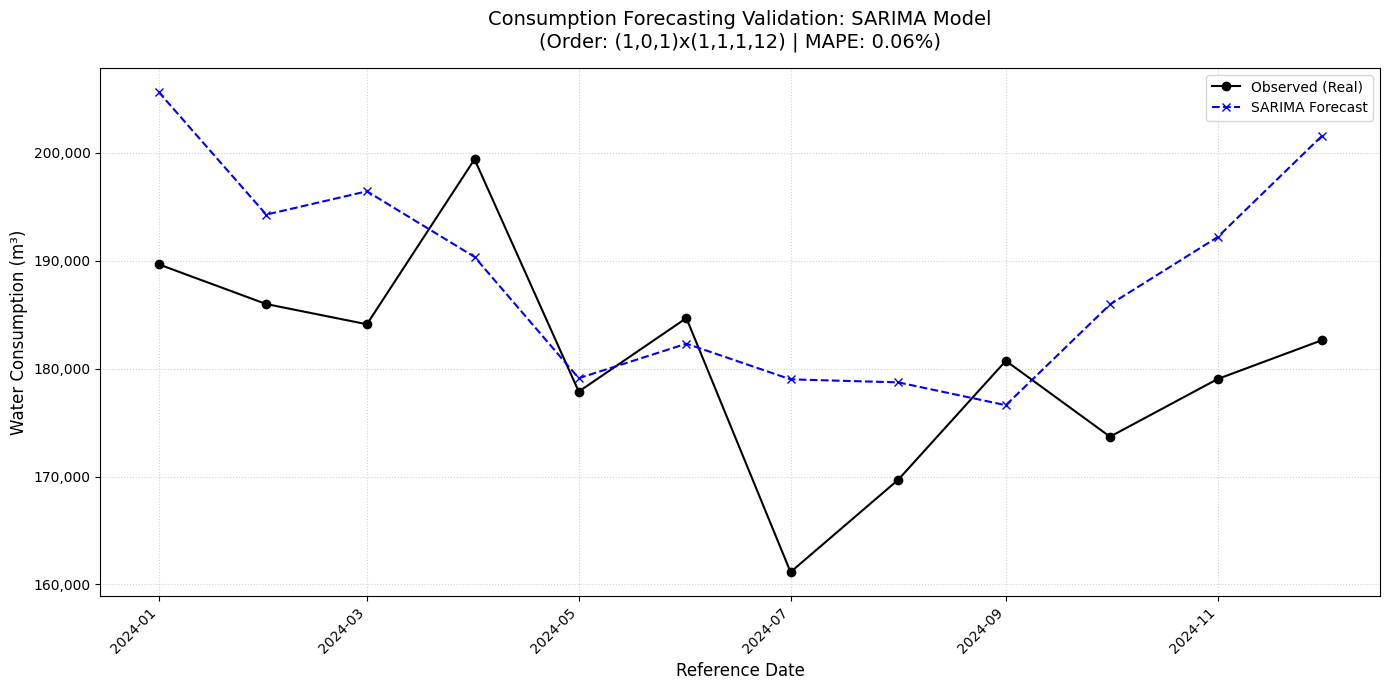

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import os
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller
from sklearn.metrics import mean_absolute_percentage_error as mape

# ==========================================
# 1. Configuration and Paths
# ==========================================
BASE_PATH = 'E:\\Projetos\\ABM-WP'
INPUT_FILE = os.path.join(BASE_PATH, 'includes', 'Tabela_consumo_Itapua_120m.csv')
OUTPUT_DIR = os.path.join(BASE_PATH, 'figuras')
OUTPUT_FIG = 'figure-sarima-forecast-validation.pdf'

def test_stationarity(series):
    """
    Performs the Augmented Dickey-Fuller (ADF) test to check for stationarity.
    """
    result = adfuller(series.dropna())
    print('--- Augmented Dickey-Fuller (ADF) Test ---')
    print(f'ADF Statistic: {result[0]:.4f}')
    print(f'p-value: {result[1]:.4f}')
    print('Critical Values:')
    for key, value in result[4].items():
        print(f'   {key}: {value:.4f}')
    
    if result[1] <= 0.05:
        print("Conclusion: The series is stationary (p <= 0.05).")
    else:
        print("Conclusion: The series is NOT stationary (p > 0.05).")

def main():
    print("--- Starting SARIMA (Seasonal ARIMA) Consumption Forecasting ---")

    # ==========================================
    # 2. Data Loading and Preparation
    # ==========================================
    if not os.path.exists(INPUT_FILE):
        print(f"Error: Input file not found at {INPUT_FILE}")
        return

    df = pd.read_csv(INPUT_FILE, sep=';')
    df['AM_REFERENCIA'] = pd.to_datetime(df['AM_REFERENCIA'], format='%Y%m')
    
    # Aggregation and Sorting
    df_aggregated = df.groupby('AM_REFERENCIA')['HCLQTCON'].sum().reset_index()
    df_aggregated = df_aggregated.sort_values(by='AM_REFERENCIA')
    ts = df_aggregated.set_index('AM_REFERENCIA')['HCLQTCON']

    # Stationarity Check
    test_stationarity(ts)

    # ==========================================
    # 3. Model Identification (ACF/PACF)
    # ==========================================
    # Differentiation if not stationary
    ts_diff = ts.diff().dropna() if adfuller(ts.dropna())[1] > 0.05 else ts

    # Optional: Visual check for p, q, P, Q parameters
    # fig_diag, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))
    # plot_acf(ts_diff, lags=min(40, len(ts_diff)-1), ax=ax1)
    # plot_pacf(ts_diff, lags=min(20, len(ts_diff)//2-1), ax=ax2)
    # plt.tight_layout()

    # ==========================================
    # 4. Train-Test Split (Chronological)
    # ==========================================
    train = ts['2015-01':'2023-12']
    test = ts['2024-01':'2024-12']

    # ==========================================
    # 5. SARIMA Modeling
    # ==========================================
    # Parameters (p,d,q) x (P,D,Q,s)
    # Note: s=12 for monthly data with annual seasonality
    print("\nFitting SARIMA model...")
    model = SARIMAX(train, order=(1, 0, 1), seasonal_order=(1, 1, 1, 12))
    model_fit = model.fit(disp=False)
    
    print("\nModel Summary:")
    print(model_fit.summary())

    # Forecasting
    predictions = model_fit.predict(start=len(train), end=len(train)+len(test)-1, dynamic=False)
    predictions.index = test.index

    # Metrics
    mape_value = mape(test, predictions)
    print(f'\nValidation MAPE: {mape_value:.2f}%')

    # Comparison Table
    comparison_df = pd.DataFrame({
        'Observed': test,
        'Predicted': predictions
    })
    print("\nComparison Results (Test Window):")
    print(comparison_df)

    # ==========================================
    # 6. Visualization and Export
    # ==========================================
    fig, ax = plt.subplots(figsize=(14, 7))
    
    ax.plot(test.index, test, label='Observed (Real)', color='black', marker='o', linestyle='-')
    ax.plot(predictions.index, predictions, label='SARIMA Forecast', color='blue', marker='x', linestyle='--')

    ax.set_title(f"Consumption Forecasting Validation: SARIMA Model\n(Order: (1,0,1)x(1,1,1,12) | MAPE: {mape_value:.2f}%)", 
                 fontsize=14, pad=15)
    ax.set_ylabel('Water Consumption (m³)', fontsize=12)
    ax.set_xlabel('Reference Date', fontsize=12)
    
    # Format Y axis with thousands separator
    ax.yaxis.set_major_formatter(mticker.StrMethodFormatter('{x:,.0f}'))
    
    plt.xticks(rotation=45, ha='right')
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.legend(loc='best', frameon=True)
    plt.tight_layout()

    # Save to PDF for LaTeX integration
    if not os.path.exists(OUTPUT_DIR): os.makedirs(OUTPUT_DIR)
    save_path = os.path.join(OUTPUT_DIR, OUTPUT_FIG)
    plt.savefig(save_path, format='pdf', bbox_inches='tight')
    
    print(f"\nSuccess! SARIMA validation chart saved at: {save_path}")
    plt.show()

if __name__ == "__main__":
    main()